In [1]:
import pandas as pd

df = pd.read_csv("chronic_kidney_disease.csv")
df.isnull().sum()


id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [2]:
print("Before:", df.shape)
df = df.dropna()
print("After:", df.shape)


Before: (400, 26)
After: (158, 26)


In [3]:
# Numerical → mean
df = df.fillna(df.mean(numeric_only=True))

# Categorical → constant
df = df.fillna("Unknown")

df.isnull().sum()


id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

In [4]:
df.dtypes

df["classification"] = df["classification"].astype("category")
df.dtypes


id                   int64
age                float64
bp                 float64
sg                 float64
al                 float64
su                 float64
rbc                    str
pc                     str
pcc                    str
ba                     str
bgr                float64
bu                 float64
sc                 float64
sod                float64
pot                float64
hemo               float64
pcv                    str
wc                     str
rc                     str
htn                    str
dm                     str
cad                    str
appet                  str
pe                     str
ane                    str
classification    category
dtype: object

In [5]:
df = df.rename(columns={
    "bp": "Blood_Pressure",
    "bgr": "Blood_Glucose"
})

df.head()


,id,age,Blood_Pressure,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
9,9,53.0,90.0,1.020,2.0,0.0,abnormal,abnormal,present,notpresent,...,29,12100,3.7,yes,yes,no,poor,no,yes,ckd
11,11,63.0,70.0,1.010,3.0,0.0,abnormal,abnormal,present,notpresent,...,32,4500,3.8,yes,yes,no,poor,yes,no,ckd
14,14,68.0,80.0,1.010,3.0,2.0,normal,abnormal,present,present,...,16,11000,2.6,yes,yes,yes,poor,yes,no,ckd
20,20,61.0,80.0,1.015,2.0,0.0,abnormal,abnormal,notpresent,notpresent,...,24,9200,3.2,yes,yes,yes,poor,yes,yes,ckd


In [6]:
df["rbc"] = df["rbc"].replace({
    "normal": "Normal",
    "abnormal": "Abnormal"
})

df["rbc"].value_counts()


rbc
Normal      140
Abnormal     18
Name: count, dtype: int64

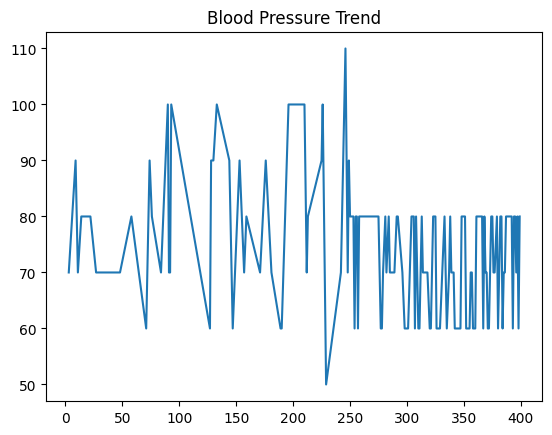

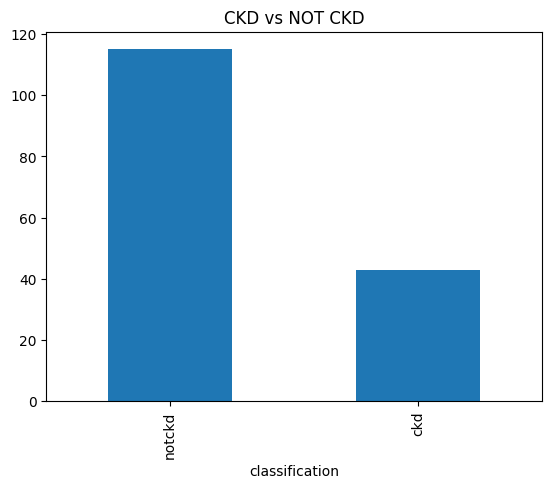

In [7]:
import matplotlib.pyplot as plt

plt.plot(df["Blood_Pressure"])
plt.title("Blood Pressure Trend")
plt.show()

df["classification"].value_counts().plot(kind="bar")
plt.title("CKD vs NOT CKD")
plt.show()


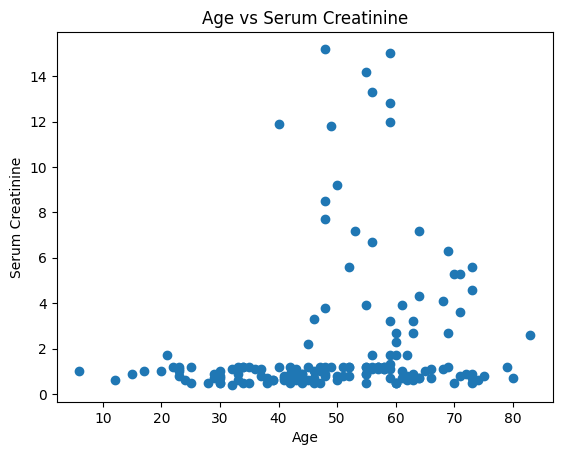

In [8]:
plt.scatter(df["age"], df["sc"])
plt.xlabel("Age")
plt.ylabel("Serum Creatinine")
plt.title("Age vs Serum Creatinine")
plt.show()


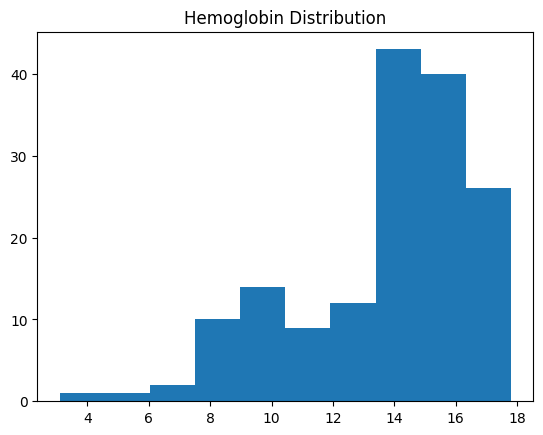

In [9]:
plt.hist(df["hemo"], bins=10)
plt.title("Hemoglobin Distribution")
plt.show()


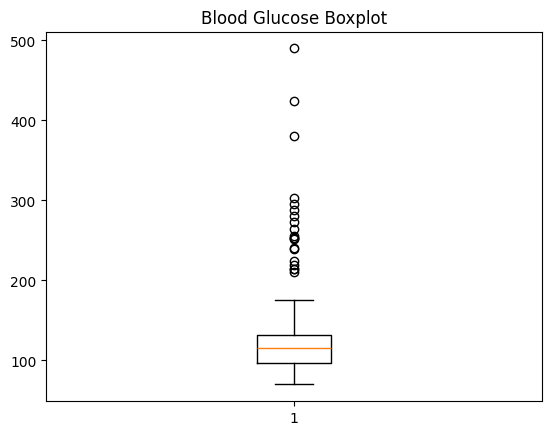

In [10]:
plt.boxplot(df["Blood_Glucose"])
plt.title("Blood Glucose Boxplot")
plt.show()
